In [6]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [31]:
tcm_df_1 = pd.read_csv("../Data/tcm_social_data_1year.csv")
tcm_df_1.shape
tcm_df_1.head()
tcm_df_1.columns


(9292, 19)

,content_type,creation_time,hashtags,id,is_branded_content,lang,match_type,mcl_url,modified_time,multimedia,post_owner.id,post_owner.name,post_owner.type,post_owner.username,statistics.comment_count,statistics.like_count,statistics.views,statistics.views_date_last_refreshed,text
0,albums,2025-11-13T22:58:26+00:00,"[""1""]",27127889526849949,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2025-11-13T22:59:24+00:00,"[{""id"":""993416640069700"",""type"":""photo"",""url"":...",7440718489305156,Dr. Brittany | Acupuncture | Fertility | Pregn...,creator,doctor.mamabear,10.0,32.0,921.0,2026-05-22,Most mamas are told to wait on allergen foods…...
1,albums,2025-11-13T22:02:06+00:00,NaN,1022065817434502,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2025-12-23T09:15:56+00:00,"[{""id"":""954924990679364"",""type"":""photo"",""url"":...",1834772577120016,Dave Casey,business,dave_casey_91,11.0,NaN,8923.0,2026-05-22,The New War Horse🐴 😈 - SEVEN82MOTORS TCM Comm...
2,videos,2025-11-13T21:34:56+00:00,NaN,1564262614583311,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2025-11-16T11:55:15+00:00,"[{""id"":""1564262614583311"",""type"":""video"",""dura...",4203096430017796,Catarina Oliveira,creator,oliveiracatarina,0.0,11.0,347.0,2026-05-22,You should really be eating warm food. \nIn Tr...
3,albums,2025-11-13T21:04:33+00:00,"[""tattoos"",""txtattoo"",""thetexaschainsawmassacr...",971250505875088,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2025-11-29T17:16:52+00:00,NaN,1501838428050873,CHRISTIAN FLORES,creator,christianflorestattooer,10.0,98.0,11665.0,2026-05-22,LEATHERFACE… This tattoo is special. Beyond th...
4,photos,2025-11-13T20:59:23+00:00,"[""amaviwellness"",""calgarytcm"",""yycherbs"",""herb...",3645286768940969,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2025-11-13T21:00:15+00:00,"[{""id"":""3645286768940969"",""type"":""photo"",""url""...",1142105050653536,calgary acupuncture | facials | wellness | laser,creator,amaviwellnessclinic,12.0,NaN,10126.0,2026-05-22,"✨ Traditional remedies, modern results ✨\n\nHo..."


Index(['content_type', 'creation_time', 'hashtags', 'id', 'is_branded_content',
       'lang', 'match_type', 'mcl_url', 'modified_time', 'multimedia',
       'post_owner.id', 'post_owner.name', 'post_owner.type',
       'post_owner.username', 'statistics.comment_count',
       'statistics.like_count', 'statistics.views',
       'statistics.views_date_last_refreshed', 'text'],
      dtype='object')

In [32]:
tcm_df_2 = pd.read_csv("../Data/tcm_social_data_6months.csv")
tcm_df_2.shape
tcm_df_2.head()
tcm_df_2.columns

(6316, 19)

,content_type,creation_time,hashtags,id,is_branded_content,lang,match_type,mcl_url,modified_time,multimedia,post_owner.id,post_owner.name,post_owner.type,post_owner.username,statistics.comment_count,statistics.like_count,statistics.views,statistics.views_date_last_refreshed,text
0,videos,2026-05-13T13:17:26+00:00,"[""\u03bf\u03bb\u03b9\u03c3\u03c4\u03b9\u03ba\u...",1019079890556970,False,el,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2026-05-13T13:26:59+00:00,"[{""id"":""1019079890556970"",""type"":""video"",""dura...",1329710432369815,Frantziou Therapist,creator,dimitrafrantziou,0.0,34.0,NaN,NaN,Κρατάς χώρο για όλους καθώς κινούνται μέσα από...
1,videos,2026-05-13T13:00:55+00:00,"[""thecrew"",""ubisoft"",""tcm"",""truck""]",2414437239040581,False,NaN,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2026-05-13T14:49:56+00:00,"[{""id"":""2414437239040581"",""type"":""video"",""dura...",1364608424253472,Theo Thomas,creator,blackpanthaayt,7.0,398.0,NaN,NaN,Can you jump into my bed? \n#tcm #thecrew #ubi...
2,videos,2026-05-13T11:57:53+00:00,"[""talhaahadroundtable"",""talhaahadpodcast"",""tal...",1656727755658052,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2026-05-13T13:13:23+00:00,"[{""id"":""1656727755658052"",""type"":""video"",""dura...",3013578955443657,Talha Ahad,creator,talhaahadpodcast,0.0,7.0,644.0,2026-05-13,"Ask AI a wrong question, it'll give you a conf..."
3,videos,2026-05-13T10:49:04+00:00,"[""titancapitalmarkets"",""tcm""]",898235766608248,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2026-05-13T11:39:08+00:00,"[{""id"":""898235766608248"",""type"":""video"",""durat...",1994846654704082,Titan Capital Markets,creator,titanscapitalmarket,3.0,37.0,1339.0,2026-05-13,From making hits…\nto hitting payouts.\n\n5ive...
4,videos,2026-05-13T05:24:32+00:00,"[""mentalhealth"",""heilung"",""tcm"",""nervensystem""...",1360004709303167,False,de,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2026-05-13T05:40:08+00:00,"[{""id"":""1360004709303167"",""type"":""video"",""dura...",981934127691940,Christine Fuchs,creator,tcm_mindset,15.0,12.0,226.0,2026-05-13,"Viele Menschen versuchen, noch stärker zu werd..."


Index(['content_type', 'creation_time', 'hashtags', 'id', 'is_branded_content',
       'lang', 'match_type', 'mcl_url', 'modified_time', 'multimedia',
       'post_owner.id', 'post_owner.name', 'post_owner.type',
       'post_owner.username', 'statistics.comment_count',
       'statistics.like_count', 'statistics.views',
       'statistics.views_date_last_refreshed', 'text'],
      dtype='object')

In [34]:
tcm_df = pd.concat([tcm_df_2, tcm_df_1])


In [35]:
# Looking at the types of Languages and types of accounts that exist
lang = tcm_df.lang.value_counts()
lang

acc_type = tcm_df["post_owner.type"].value_counts()
acc_type


lang
en    12942
de      633
pt      306
id      266
pl      159
sv       99
es       86
nl       82
zh       74
fi       50
ml       48
th       36
ja       31
tr       26
fa       23
it       22
ar       15
cs       14
hi       13
el       13
fr       10
ru        7
da        6
mn        4
bn        3
jv        3
su        2
ss        2
ms        2
no        2
vi        2
wy        2
mr        2
qu        2
ta        2
ko        2
tl        2
bs        1
sw        1
hr        1
cb        1
qp        1
li        1
ts        1
om        1
gn        1
te        1
sn        1
uk        1
hu        1
sk        1
Name: count, dtype: int64

post_owner.type
creator     9290
business    6132
personal     186
Name: count, dtype: int64

In [36]:

tcm_df = tcm_df[tcm_df["lang"] == "en"].copy()


tcm_df["hashtags_extracted"] = tcm_df["text"].str.findall(r"#\w+")


tcm_df["text_clean"] = tcm_df["text"].str.replace(r"#\w+", "", regex=True)

tcm_df["text_clean"] = tcm_df["text_clean"].str.replace(r"\s+", " ", regex=True).str.strip()



In [37]:
from datetime import datetime, timedelta
! pip install plotnine
import plotnine
from plotnine import *
import random
import seaborn as sns

In [38]:
tcm_df["creation_time"] = pd.to_datetime(tcm_df["creation_time"])

tcm_df["creation_time"] = tcm_df["creation_time"].dt.tz_localize(None)

tcm_df["week"] = tcm_df["creation_time"].dt.to_period("W").dt.to_timestamp()

In [39]:
df_tcm = (
    tcm_df
    .groupby(["week", "post_owner.type"])
    .size()
    .reset_index(name="count")
)
df_tcm["total"] = df_tcm.groupby("week")["count"].transform("sum")
df_tcm["proportion"] = df_tcm["count"] / df_tcm["total"]

<Figure size 2000x1000 with 0 Axes>

<Axes: xlabel='week', ylabel='proportion'>

(array([20209., 20270., 20332., 20393., 20454., 20513., 20574.]),
 [Text(20209.0, 0, '2025-05'),
  Text(20270.0, 0, '2025-07'),
  Text(20332.0, 0, '2025-09'),
  Text(20393.0, 0, '2025-11'),
  Text(20454.0, 0, '2026-01'),
  Text(20513.0, 0, '2026-03'),
  Text(20574.0, 0, '2026-05')])

(array([-0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8]),
 [Text(0, -0.1, '−0.1'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.1, '0.1'),
  Text(0, 0.20000000000000004, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5000000000000001, '0.5'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.7000000000000001, '0.7'),
  Text(0, 0.8, '0.8')])

Text(0.5, 0, 'Week')

Text(0, 0.5, 'Proportion of #tcm Posts')

Text(0.5, 1.0, '#tcm Posts Over Time: Creator vs Business vs Personal')

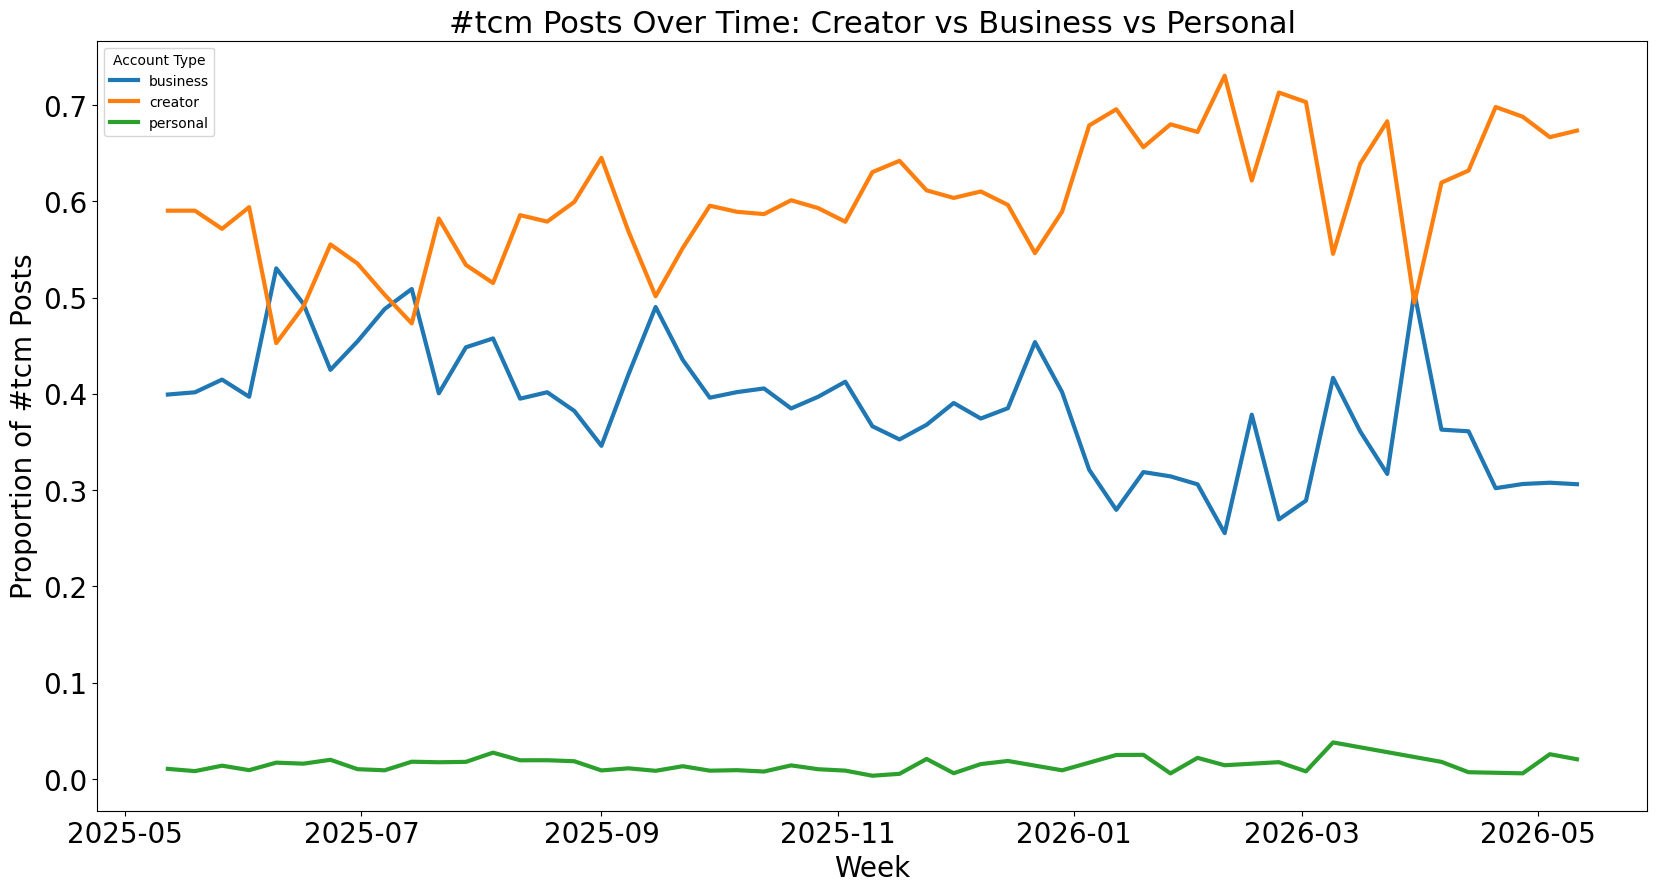

<Figure size 640x480 with 0 Axes>

In [40]:
plt.figure(figsize=(20,10))

sns.lineplot(
    data=df_tcm,
    x="week",
    y="proportion",
    hue="post_owner.type",
    linewidth=3
)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Week", fontsize=20)
plt.ylabel("Proportion of #tcm Posts", fontsize=20)
plt.title("#tcm Posts Over Time: Creator vs Business vs Personal", fontsize=22)

plt.legend(title="Account Type")
plt.show()

plt.savefig("../Output/tcm__proportion_posts_over_time.png")

<Figure size 2000x1000 with 0 Axes>

<Axes: xlabel='week', ylabel='count'>

(array([20209., 20270., 20332., 20393., 20454., 20513., 20574.]),
 [Text(20209.0, 0, '2025-05'),
  Text(20270.0, 0, '2025-07'),
  Text(20332.0, 0, '2025-09'),
  Text(20393.0, 0, '2025-11'),
  Text(20454.0, 0, '2026-01'),
  Text(20513.0, 0, '2026-03'),
  Text(20574.0, 0, '2026-05')])

(array([-50.,   0.,  50., 100., 150., 200., 250.]),
 [Text(0, -50.0, '−50'),
  Text(0, 0.0, '0'),
  Text(0, 50.0, '50'),
  Text(0, 100.0, '100'),
  Text(0, 150.0, '150'),
  Text(0, 200.0, '200'),
  Text(0, 250.0, '250')])

Text(0.5, 0, 'Week')

Text(0, 0.5, 'Total #tcm Posts')

Text(0.5, 1.0, '#tcm Posts Over Time: Creator vs Business vs Personal')

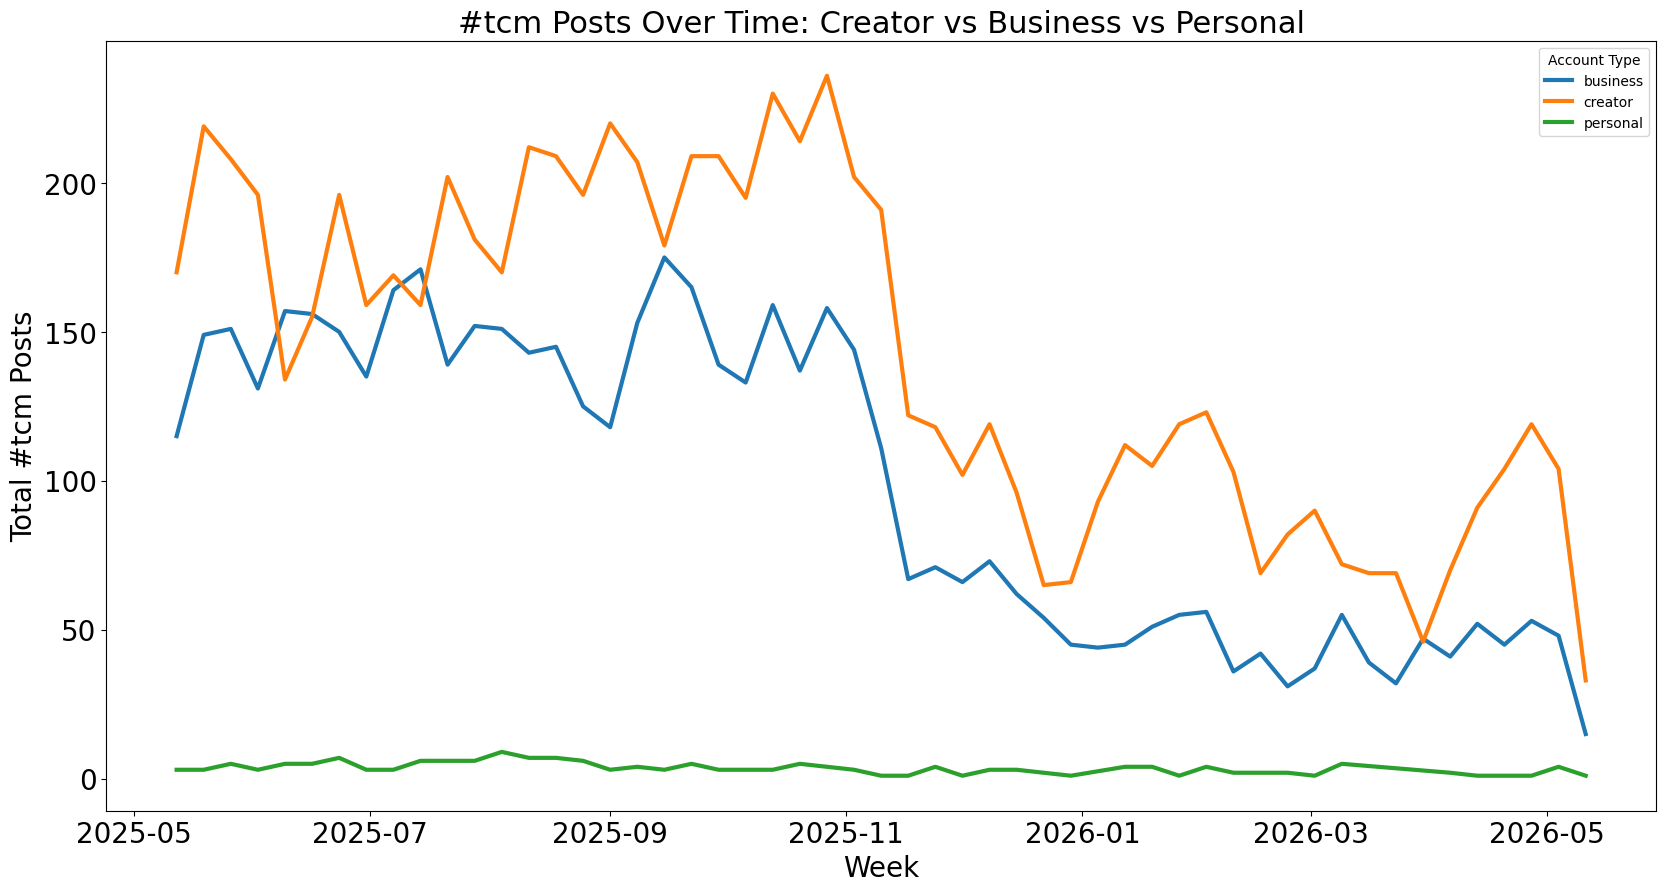

<Figure size 640x480 with 0 Axes>

In [41]:
plt.figure(figsize=(20,10))

sns.lineplot(
    data=df_tcm,
    x="week",
    y="count",
    hue="post_owner.type",
    linewidth=3
)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Week", fontsize=20)
plt.ylabel("Total #tcm Posts", fontsize=20)
plt.title("#tcm Posts Over Time: Creator vs Business vs Personal", fontsize=22)

plt.legend(title="Account Type")
plt.show()
plt.savefig("../Output/tcm_posts_over_time.png")

In [42]:
df_tcm = (
    tcm_df
    .groupby(["week", "post_owner.type"])["post_owner.id"]
    .nunique()
    .reset_index(name="unique_owners")
)

df_tcm["total"] = df_tcm.groupby("week")["unique_owners"].transform("sum")

<Figure size 2000x1000 with 0 Axes>

<Axes: xlabel='week', ylabel='unique_owners'>

(array([20209., 20270., 20332., 20393., 20454., 20513., 20574.]),
 [Text(20209.0, 0, '2025-05'),
  Text(20270.0, 0, '2025-07'),
  Text(20332.0, 0, '2025-09'),
  Text(20393.0, 0, '2025-11'),
  Text(20454.0, 0, '2026-01'),
  Text(20513.0, 0, '2026-03'),
  Text(20574.0, 0, '2026-05')])

(array([-20.,   0.,  20.,  40.,  60.,  80., 100., 120., 140., 160.]),
 [Text(0, -20.0, '−20'),
  Text(0, 0.0, '0'),
  Text(0, 20.0, '20'),
  Text(0, 40.0, '40'),
  Text(0, 60.0, '60'),
  Text(0, 80.0, '80'),
  Text(0, 100.0, '100'),
  Text(0, 120.0, '120'),
  Text(0, 140.0, '140'),
  Text(0, 160.0, '160')])

Text(0.5, 0, 'Week')

Text(0, 0.5, 'Number of Unique Users')

Text(0.5, 1.0, 'Proportion of Unique #tcm Participants Over Time by Account Type')

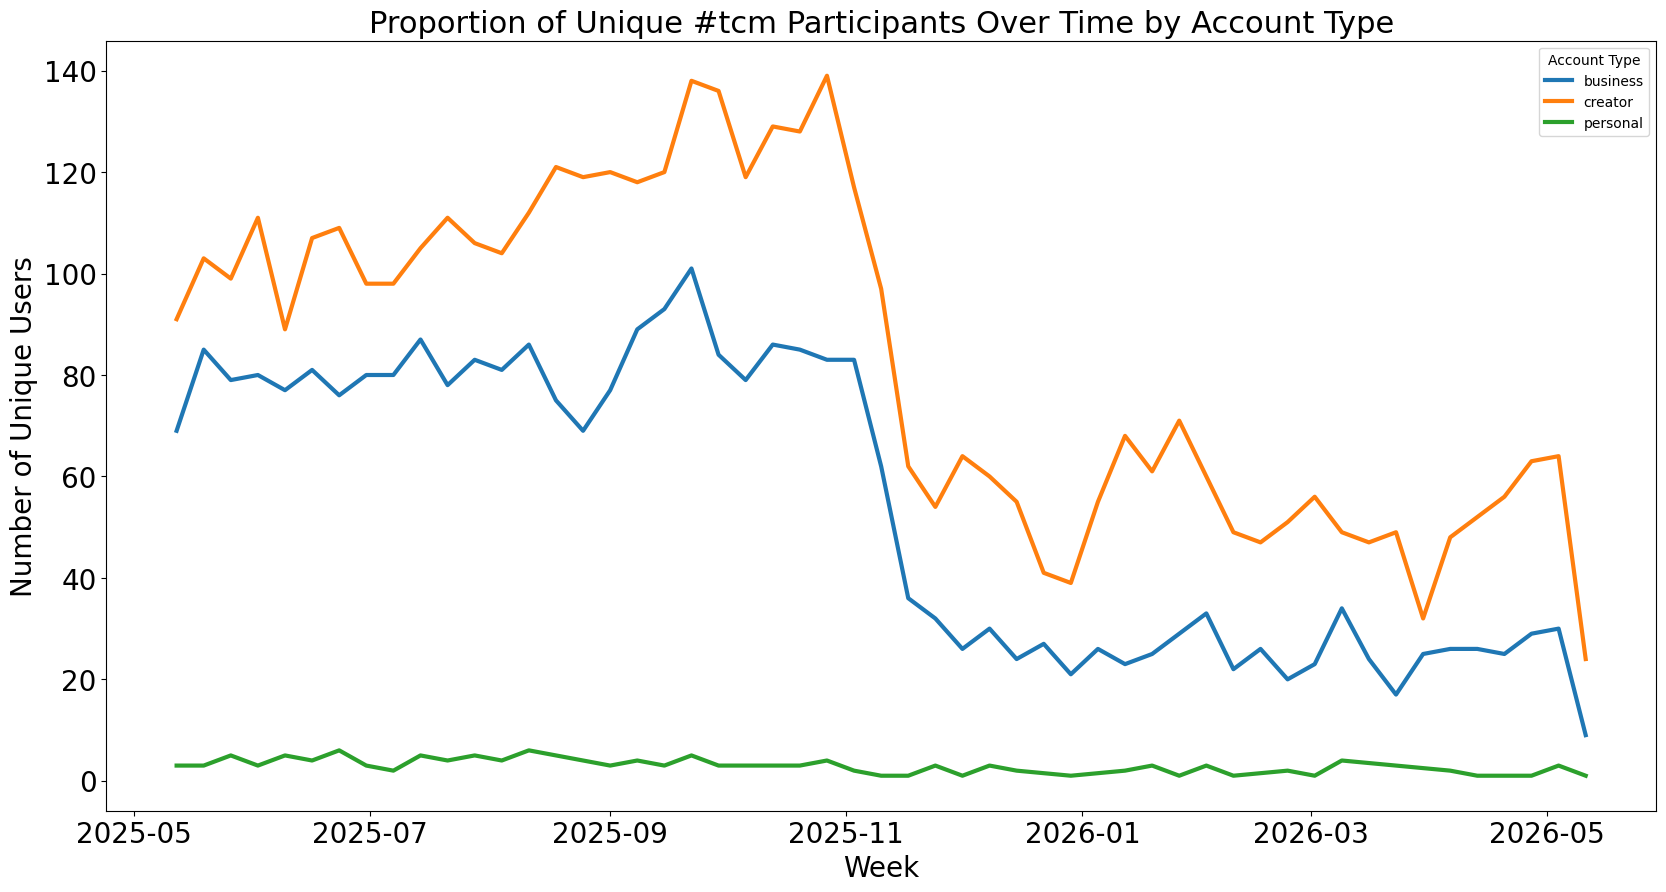

<Figure size 640x480 with 0 Axes>

In [43]:
plt.figure(figsize=(20,10))

sns.lineplot(
    data=df_tcm,
    x="week",
    y="unique_owners",
    hue="post_owner.type",
    linewidth=3
)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Week", fontsize=20)
plt.ylabel("Number of Unique Users", fontsize=20)
plt.title("Proportion of Unique #tcm Participants Over Time by Account Type", fontsize=22)

plt.legend(title="Account Type")
plt.show()

plt.savefig("../Output/tcm_proportion_unique_users_over_time.png")

In [44]:
tcm_df["first_week"] = tcm_df.groupby("post_owner.id")["week"].transform("min")

tcm_df["is_new"] = tcm_df["week"] == tcm_df["first_week"]


In [45]:
new_users = (
    tcm_df[tcm_df["is_new"]]
    .groupby(["week", "post_owner.type"])["post_owner.id"]
    .nunique()
    .reset_index(name="new_users")
)

In [46]:
df_tcm = df_tcm.merge(new_users, on=["week", "post_owner.type"], how="left")
df_tcm["new_users"] = df_tcm["new_users"].fillna(0)

<Figure size 2000x1000 with 0 Axes>

<Axes: xlabel='week', ylabel='unique_owners'>

<Axes: xlabel='week', ylabel='unique_owners'>

(array([20209., 20270., 20332., 20393., 20454., 20513., 20574.]),
 [Text(20209.0, 0, '2025-05'),
  Text(20270.0, 0, '2025-07'),
  Text(20332.0, 0, '2025-09'),
  Text(20393.0, 0, '2025-11'),
  Text(20454.0, 0, '2026-01'),
  Text(20513.0, 0, '2026-03'),
  Text(20574.0, 0, '2026-05')])

(array([-20.,   0.,  20.,  40.,  60.,  80., 100., 120., 140., 160.]),
 [Text(0, -20.0, '−20'),
  Text(0, 0.0, '0'),
  Text(0, 20.0, '20'),
  Text(0, 40.0, '40'),
  Text(0, 60.0, '60'),
  Text(0, 80.0, '80'),
  Text(0, 100.0, '100'),
  Text(0, 120.0, '120'),
  Text(0, 140.0, '140'),
  Text(0, 160.0, '160')])

Text(0.5, 0, 'Week')

Text(0, 0.5, 'Number of Users')

Text(0.5, 1.0, 'Total vs New #tcm Participants Over Time by Account Type')

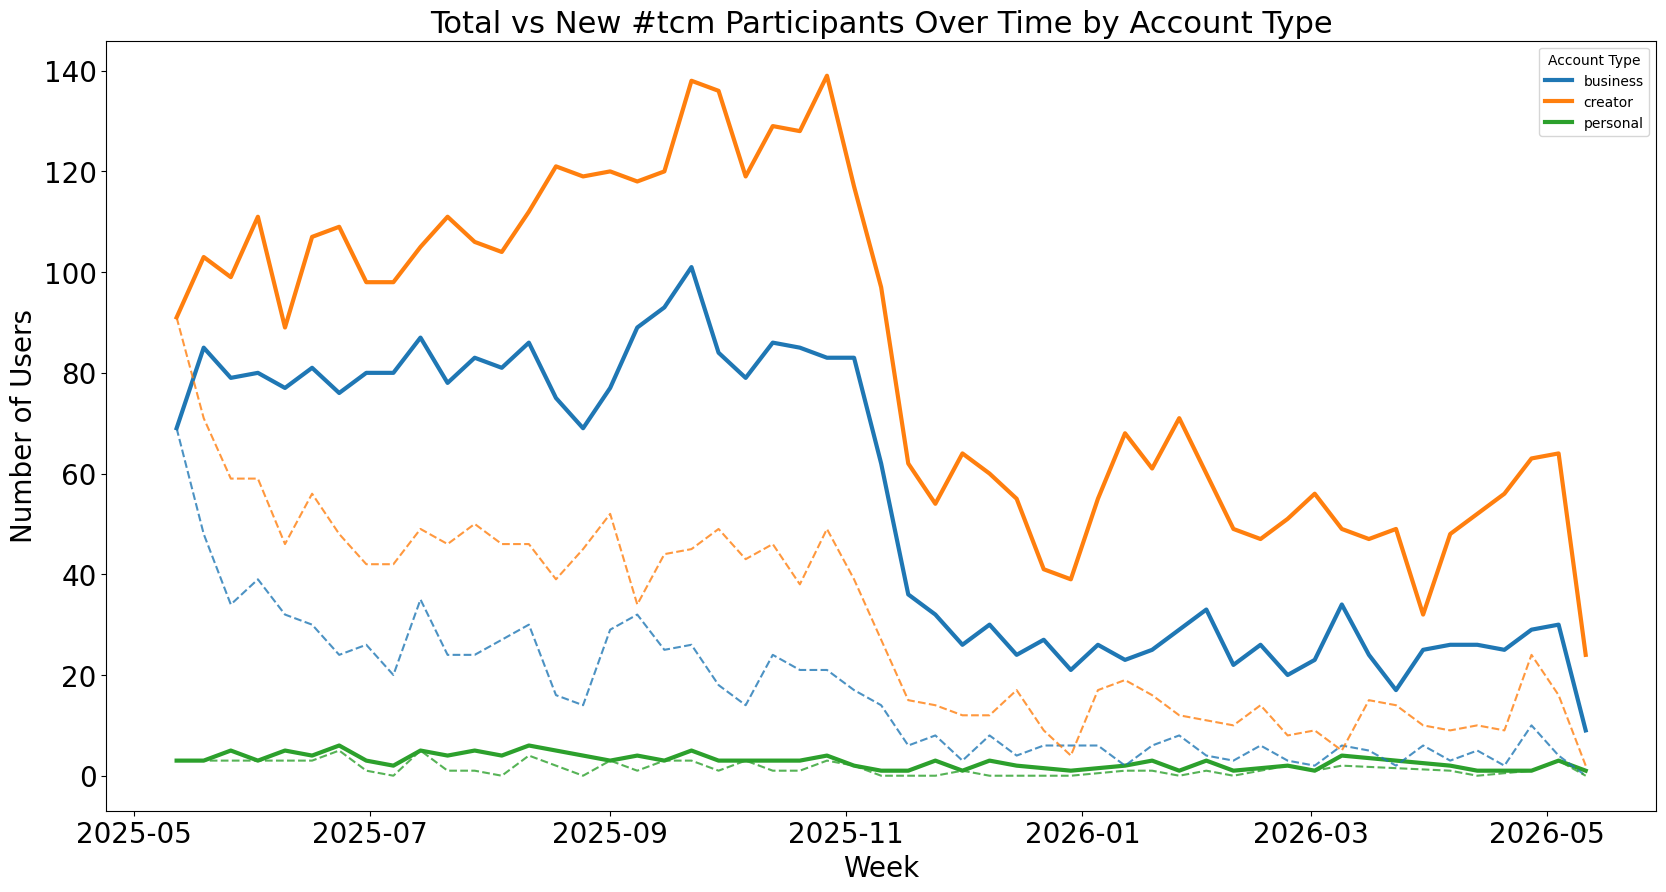

<Figure size 640x480 with 0 Axes>

In [47]:
plt.figure(figsize=(20,10))

# total unique users (solid)
sns.lineplot(
    data=df_tcm,
    x="week",
    y="unique_owners",
    hue="post_owner.type",
    linewidth=3
)

# new users (dashed style via alpha)
sns.lineplot(
    data=df_tcm,
    x="week",
    y="new_users",
    hue="post_owner.type",
    linestyle="--",
    alpha=0.8,
    legend=False  # avoids duplicate legend
)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Week", fontsize=20)
plt.ylabel("Number of Users", fontsize=20)
plt.title("Total vs New #tcm Participants Over Time by Account Type", fontsize=22)

plt.legend(title="Account Type")
plt.show()

plt.savefig("../Output/tcm_total_new_users_over_time.png")

In [49]:
# what are the most common hashtags paired with #tcm
tcm_df.head()

,content_type,creation_time,hashtags,id,is_branded_content,lang,match_type,mcl_url,modified_time,multimedia,...,statistics.comment_count,statistics.like_count,statistics.views,statistics.views_date_last_refreshed,text,hashtags_extracted,text_clean,week,first_week,is_new
2,videos,2026-05-13 11:57:53,"[""talhaahadroundtable"",""talhaahadpodcast"",""tal...",1656727755658052,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2026-05-13T13:13:23+00:00,"[{""id"":""1656727755658052"",""type"":""video"",""dura...",...,0.0,7.0,644.0,2026-05-13,"Ask AI a wrong question, it'll give you a conf...","[#talhaahad, #talhaahadroundtable, #aiseries, ...","Ask AI a wrong question, it'll give you a conf...",2026-05-11,2025-07-21,False
3,videos,2026-05-13 10:49:04,"[""titancapitalmarkets"",""tcm""]",898235766608248,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2026-05-13T11:39:08+00:00,"[{""id"":""898235766608248"",""type"":""video"",""durat...",...,3.0,37.0,1339.0,2026-05-13,From making hits…\nto hitting payouts.\n\n5ive...,"[#titancapitalmarkets, #tcm]",From making hits… to hitting payouts. 5ivebeat...,2026-05-11,2025-05-12,False
5,videos,2026-05-13 02:11:45,"[""healthy"",""missmaya"",""tcm"",""wellness"",""guasha""]",980906014454966,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2026-05-13T02:42:14+00:00,"[{""id"":""980906014454966"",""type"":""video"",""durat...",...,0.0,3.0,861.0,2026-05-13,#tcm #missmaya #guasha #healthy #wellness,"[#tcm, #missmaya, #guasha, #healthy, #wellness]",,2026-05-11,2025-09-01,False
6,albums,2026-05-13 01:57:36,"[""chinesemedicineworks"",""pmos"",""tcm"",""acupunct...",1016501597388882,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2026-05-13T01:59:21+00:00,"[{""id"":""744512645356645"",""type"":""photo"",""url"":...",...,1.0,34.0,637.0,2026-05-13,For my TCM patients honestly not much changes ...,"[#PCOS, #PMOS, #chinesemedicineworks, #acupunc...",For my TCM patients honestly not much changes ...,2026-05-11,2025-05-12,False
7,videos,2026-05-13 01:45:00,"[""insomnia"",""kidney1"",""sleepbetter"",""acupressu...",1330654912458872,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2026-05-13T01:55:52+00:00,"[{""id"":""1330654912458872"",""type"":""video"",""dura...",...,4.0,84.0,3309.0,2026-05-13,Can’t sleep? Anger issues? 😤 Meet Kidney 1! 🦶✨...,"[#AcupressurePoints, #Kidney1, #TCM, #Insomnia...",Can’t sleep? Anger issues? 😤 Meet Kidney 1! 🦶✨...,2026-05-11,2025-05-12,False


In [51]:
common_hashtags = (tcm_df["hashtags_extracted"].explode().str.lower().value_counts().head(20))
common_hashtags

hashtags_extracted
#tcm                           7699
#chinesemedicine               1954
#traditionalchinesemedicine    1386
#holistichealth                1084
#wellness                      1007
#acupuncture                    790
#acupressure                    537
#health                         522
#naturalhealing                 499
#womenshealth                   463
#holistichealing                453
#qigong                         393
#tcmnews                        383
#thecentrummedia                373
#tcmoriginal                    372
#tcmshorts                      372
#pakistan                       371
#tcmredofficial                 371
#tcmbusinessofficial            370
#tcmpodcast                     369
Name: count, dtype: int64

In [ ]:
tcm_df

In [48]:
## Notes for vic
## 1. what hashtags often pair with #tcm
#separate the #s into a different column from the text 
## 4. Map it over time
# look at businesses vs creators using #tcm over time. 
# Sentiment analysis to understand how people use the hashtags over time, selling products or personal. 